# Klimadaten ecad E-OBS HOM

### Historische beobachtete Daten von 1950 - 2018

## 1. Importieren Dependencies und Setup

In [10]:
import xarray as xr
import numpy as np
import pandas as pd
import packaging as pg
import netCDF4 as n4
import scipy as sc
import pydap as pp
import geopandas as gpd
import regionmask
import sys
import geodatasets
import matplotlib.pyplot as plt
from matplotlib.colors import ListedColormap, BoundaryNorm
from scipy.stats import linregress
import seaborn as sns
from matplotlib.ticker import MultipleLocator
import fiona
from pathlib import Path
from matplotlib.patches import Patch

In [11]:
# Okabe-Ito-Farbpalette für farbenblind-freundliche Visualisierungen
ZONE_ORDER = ["Midlands", "Pre-Alps", "Alps"]

ZONE_COLORS = {
    "Midlands": "#E69F00",   # orange
    "Pre-Alps": "#009E73",   # green
    "Alps": "#0072B2",       # blue
}

ZONE_COLORS_MAP = {
    "Midlands": "#F6C85F",   # lighter orange
    "Pre-Alps": "#7BC8A4",   # lighter green
    "Alps": "#6BAED6",       # lighter blue
}

WINTER_COLOR = "#56B4E9"      # sky blue
SUMMER_COLOR = "#CC79A7"      # purple/pink

# Deutsches Mapping auf dieselben Okabe-Ito-Werte für die Höhenzonen in diesem Notebook
ZONEN_REIHENFOLGE = ["Mittelland", "Voralpen", "Hochgebirge"]
ZONEN_FARBEN = {
    "Mittelland": ZONE_COLORS["Midlands"],
    "Voralpen": ZONE_COLORS["Pre-Alps"],
    "Hochgebirge": ZONE_COLORS["Alps"],
}

# Mapping der deutschen Zonennamen auf die englischen Spalten-/Wertebezeichnungen,
# wie sie die Plotly-App beim Import erwartet.
ZONEN_EXPORT_NAMEN = {
    "Mittelland": "Midlands",
    "Voralpen": "Pre-Alps",
    "Hochgebirge": "Alps",
}

Flag für Run All: Keine überflüssigen Exporte machen (grosse Dateien)

In [12]:
DO_EXPORT = False #True schreibt alle vorgesehenen CSV/NetCDF/GeoJSON files

## 2. Daten importieren

In [13]:
# aktuelles Notebook-Verzeichnis
BASE_DIR = Path().resolve()
# zum Projekt-Root hochgehen
PROJECT_ROOT = BASE_DIR.parent

# Pfade definieren
RAW_DIR = PROJECT_ROOT / "data" / "raw"
PROCESSED_DIR = PROJECT_ROOT / "data" / "processed"
EXPORT_DIR = PROJECT_ROOT / "exports"


Das Notebook lädt die tägliche Mitteltemperatur (TG), die tägliche Höchsttemperatur (TX) sowie das zugehörige Höhenraster. Die Rohdaten im NetCDF-Format sind lokal im Ordner data/raw gespeichert und werden aufgrund ihrer Dateigröße nicht im Git-Repository abgelegt.

In [14]:
# Temperatur Durchschnitt laden
ds_tg = xr.open_dataset(RAW_DIR/"tg_ens_mean_0.1deg_reg_v19.0eHOM.nc")

# Temperatur Max laden
ds_tx = xr.open_dataset(RAW_DIR/"tx_ens_mean_0.1deg_reg_v19.0eHOM.nc")

# Höhenraster laden
ds_ele = xr.open_dataset(RAW_DIR/"elev_ens_0.1deg_reg_v20.0e.nc")

print(ds_tg)
print(ds_tx)
print(ds_ele)

<xarray.Dataset> Size: 33GB
Dimensions:    (time: 25171, latitude: 465, longitude: 705)
Coordinates:
  * time       (time) datetime64[ns] 201kB 1950-01-01 1950-01-02 ... 2018-11-30
  * latitude   (latitude) float64 4kB 25.05 25.15 25.25 ... 71.25 71.35 71.45
  * longitude  (longitude) float64 6kB -24.95 -24.85 -24.75 ... 45.35 45.45
Data variables:
    tg         (time, latitude, longitude) float32 33GB ...
Attributes:
    CDI:          Climate Data Interface version 1.6.9 (http://mpimet.mpg.de/...
    Conventions:  CF-1.4
    history:      Mon Apr 15 15:11:11 2019: cdo copy tg_ensmean_master.nc tg_...
    CDO:          Climate Data Operators version 1.6.9 (http://mpimet.mpg.de/...
<xarray.Dataset> Size: 33GB
Dimensions:    (time: 25171, latitude: 465, longitude: 705)
Coordinates:
  * time       (time) datetime64[ns] 201kB 1950-01-01 1950-01-02 ... 2018-11-30
  * latitude   (latitude) float64 4kB 25.05 25.15 25.25 ... 71.25 71.35 71.45
  * longitude  (longitude) float64 6kB -24.95 -24.

Es handelt sich um spatio-temporal continuous multivariate data, raumzeitliche Klimadaten: Jede Rasterzelle besitzt geografische Koordinaten, tägliche Zeitschritte und durchgehende Temperaturwerte.

## 3. Daten auf die Schweiz zuschneiden

In [15]:
# Schweiz-Grenze laden
schweiz = gpd.read_file("../data/raw/swissBOUNDARIES3D_1_5_LV95_LN02.gpkg")


C:\Users\danie\OneDrive\FHNW DS\GitProjects\klimadaten-storytelling\.venv\Lib\site-packages\pyogrio\geopandas.py:382: UserWarning: More than one layer found in 'swissBOUNDARIES3D_1_5_LV95_LN02.gpkg': 'tlm_hoheitsgrenze' (default), 'tlm_hoheitsgebiet', 'tlm_bezirksgebiet', 'tlm_landesgebiet', 'tlm_kantonsgebiet'. Specify layer parameter to avoid this warning.
  result = read_func(


In [16]:
print(fiona.listlayers(RAW_DIR/"swissBOUNDARIES3D_1_5_LV95_LN02.gpkg"))

['tlm_hoheitsgrenze', 'tlm_hoheitsgebiet', 'tlm_bezirksgebiet', 'tlm_landesgebiet', 'tlm_kantonsgebiet']


In [17]:
schweiz = gpd.read_file(
    "../data/raw/swissBOUNDARIES3D_1_5_LV95_LN02.gpkg",
    layer="tlm_landesgebiet"
)

In [18]:
schweiz = schweiz.to_crs("EPSG:4326")

<Axes: >

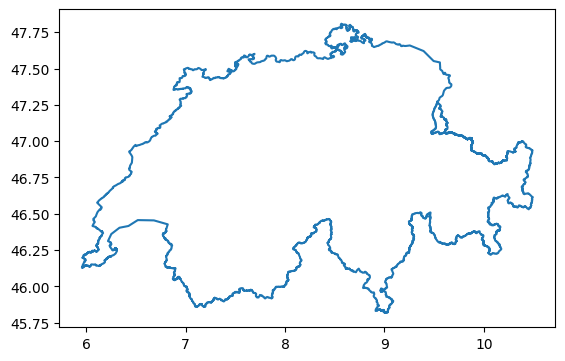

In [19]:
schweiz.boundary.plot()

In [20]:
ds_tg_ch = ds_tg.sel(
    longitude=slice(5.5, 10.7),
    latitude=slice(45.7, 47.9)
)

In [21]:
ds_tx_ch = ds_tx.sel(
    longitude=slice(5.5, 10.7),
    latitude=slice(45.7, 47.9)
)

Der E-OBS-Datensatz umfasst Europa. Für dieses Projekt werden die Daten räumlich auf ein ungefähres Begrenzungsrechteck um die Schweiz zugeschnitten, bevor spezifischere räumliche und höhenbasierte Verarbeitungen angewendet werden.Das Höhenraster wird auf die beiden Temperaturgitter abgebildet, um die Rasterzellen den Höhenzonen zuzuordnen.

In [22]:
elevation_tg = ds_ele.sel(
    longitude=ds_tg_ch.longitude,
    latitude=ds_tg_ch.latitude,
    method="nearest"
)["elevation"].copy()

elevation_tg = elevation_tg.assign_coords(
    latitude=ds_tg_ch["latitude"],
    longitude=ds_tg_ch["longitude"]
)

In [23]:
elevation_tx = ds_ele.sel(
    longitude=ds_tx_ch.longitude,
    latitude=ds_tx_ch.latitude,
    method="nearest"
)["elevation"].copy()

elevation_tx = elevation_tx.assign_coords(
    latitude=ds_tx_ch["latitude"],
    longitude=ds_tx_ch["longitude"]
)

## 4. Höhenzonen

Um Klimamuster in verschiedenen topografischen Regionen zu vergleichen, wird jede Rasterzelle einer von drei Höhenzonen zugeordnet. Die Schwellenwerte wurden so gewählt, dass sie breite und allgemein verständliche Schweizer Landschaftsregionen abbilden, anstatt hochdetaillierte topografische Klassen.

- Mittelland: bis unter 700 m über dem Meeresspiegel
- Voralpen: 700 m bis unter 1500 m über dem Meeresspiegel
- Alpen: 1500 m und darüber

Diese Vereinfachung reduziert die visuelle Komplexität und erleichtert spätere Vergleiche für nicht-fachkundige Leser:innen.

### 4.1 Zonen mappen und prüfen

In [24]:
zone_tg = xr.full_like(elevation_tg, fill_value=np.nan)
zone_tg = xr.where(elevation_tg < 700, 1, zone_tg)   #Mittelland
zone_tg = xr.where((elevation_tg >= 700) & (elevation_tg < 1500), 2, zone_tg)  #Voralpen
zone_tg = xr.where(elevation_tg >= 1500, 3, zone_tg)                              #Alpen

In [25]:
print(zone_tg.longitude.min().item(), zone_tg.longitude.max().item())
print(zone_tg.latitude.min().item(), zone_tg.latitude.max().item())
print(schweiz.total_bounds)

5.549860368784714 10.649860348382095
45.74986054596728 47.84986053917589
[ 5.95590199 45.81795858 10.49217186 47.80845449]


In [26]:
print("min elevation:", float(elevation_tx.min()))

print(
    "cells below 300m:",
    int((elevation_tx < 300).sum())
)

print(
    "cells below 300m (%):",
    float((elevation_tx < 300).mean() * 100)
)

min elevation: 209.65277099609375
cells below 300m: 71
cells below 300m (%): 6.206293706293707


In [27]:
zone_tx = xr.full_like(elevation_tx, fill_value=np.nan)
zone_tx = xr.where(elevation_tx < 700, 1, zone_tx)
zone_tx = xr.where((elevation_tx >= 700) & (elevation_tx < 1500), 2, zone_tx)
zone_tx = xr.where(elevation_tx >= 1500, 3, zone_tx)

In [28]:
#NaN-Werte befüllen mit nearest fill
zone_tg = zone_tg.ffill(dim="longitude").bfill(dim="longitude")
zone_tg = zone_tg.ffill(dim="latitude").bfill(dim="latitude")
zone_tx = zone_tx.ffill(dim="longitude").bfill(dim="longitude")
zone_tx = zone_tx.ffill(dim="latitude").bfill(dim="latitude")

In [29]:
#Check ob Zonen plausibel
print("Mittelland:", int((zone_tg == 1).sum().item()))
print("Voralpen:", int((zone_tg == 2).sum().item()))
print("Hochgebirge:", int((zone_tg == 3).sum().item()))

Mittelland: 440
Voralpen: 386
Hochgebirge: 318


In [30]:
#Check ob Zonen plausibel
print("Mittelland:", int((zone_tx == 1).sum().item()))
print("Voralpen:", int((zone_tx == 2).sum().item()))
print("Hochgebirge:", int((zone_tx == 3).sum().item()))

Mittelland: 440
Voralpen: 386
Hochgebirge: 318


Im Laufe des Projekts stellte sich heraus, dass eine Zonen-Datei für beide Variablen ts und tx eigentlich ausgereicht hätte. Da das Handling jedoch nicht wesentlich komplizierter wird, wurde das ursprüngliche Design beibehalten.

### 4.2 Export Zonen-Daten für Dashboard

In [31]:
if DO_EXPORT:
    zone_tg.to_netcdf(EXPORT_DIR/"zone_tg.nc")
    zone_tx.to_netcdf(EXPORT_DIR/"zone_tx.nc")

### 4.3 Visualisierung der Höhenzonen

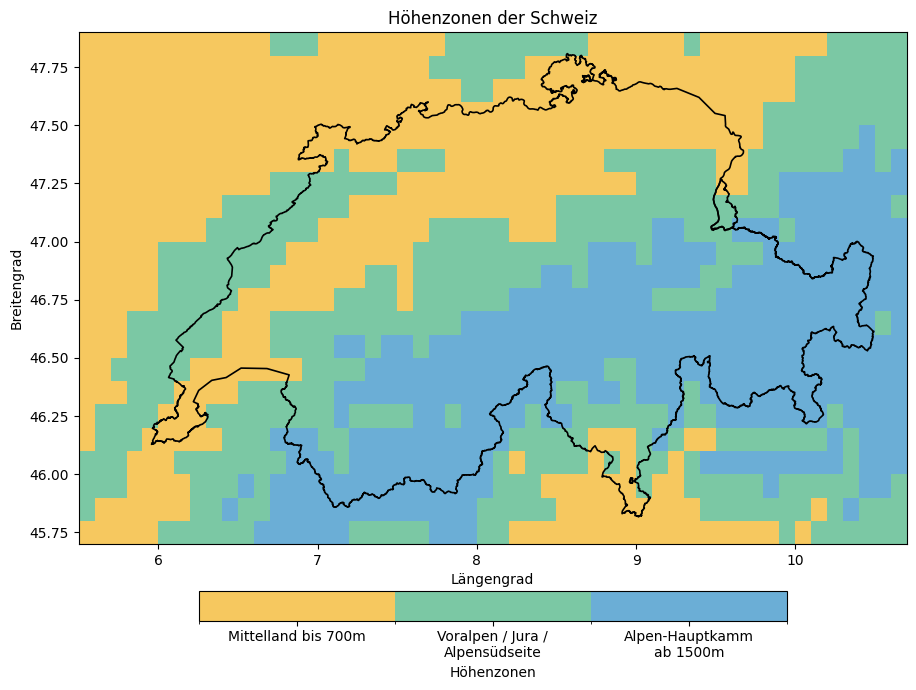

In [32]:
# Okabe-Ito-Kartenfarben (hellere Varianten) in Zonenreihenfolge 1=Mittelland, 2=Voralpen, 3=Hochgebirge
cmap = ListedColormap([
    ZONE_COLORS_MAP["Midlands"],
    ZONE_COLORS_MAP["Pre-Alps"],
    ZONE_COLORS_MAP["Alps"],
])
bounds = [0.5, 1.5, 2.5, 3.5]
norm = BoundaryNorm(bounds, cmap.N)

fig, ax = plt.subplots(figsize=(10, 7))

mappable = zone_tg.plot(
    ax=ax,
    cmap=cmap,
    norm=norm,
    add_colorbar=False
)

schweiz.boundary.plot(
    ax=ax,
    color="black",
    linewidth=1.2,
    zorder=20
)

cbar = fig.colorbar(
    mappable,
    ax=ax,
    orientation="horizontal",
    pad=0.08,
    fraction=0.05,
    ticks=[1, 2, 3]
)
cbar.set_label("Höhenzonen")
cbar.set_ticklabels([
    "Mittelland bis 700m",
    "Voralpen / Jura /\nAlpensüdseite",
    "Alpen-Hauptkamm\nab 1500m"
])

mean_lat = float(zone_tg.latitude.mean())
ax.set_aspect(1 / np.cos(np.deg2rad(mean_lat))) #Kompensiert Verzerrung der Längengrade. Die x-Achse wird gestreckt für die korrekten Proportionen

ax.set_title("Höhenzonen der Schweiz")
ax.set_xlabel("Längengrad")
ax.set_ylabel("Breitengrad")

plt.tight_layout()
plt.show()

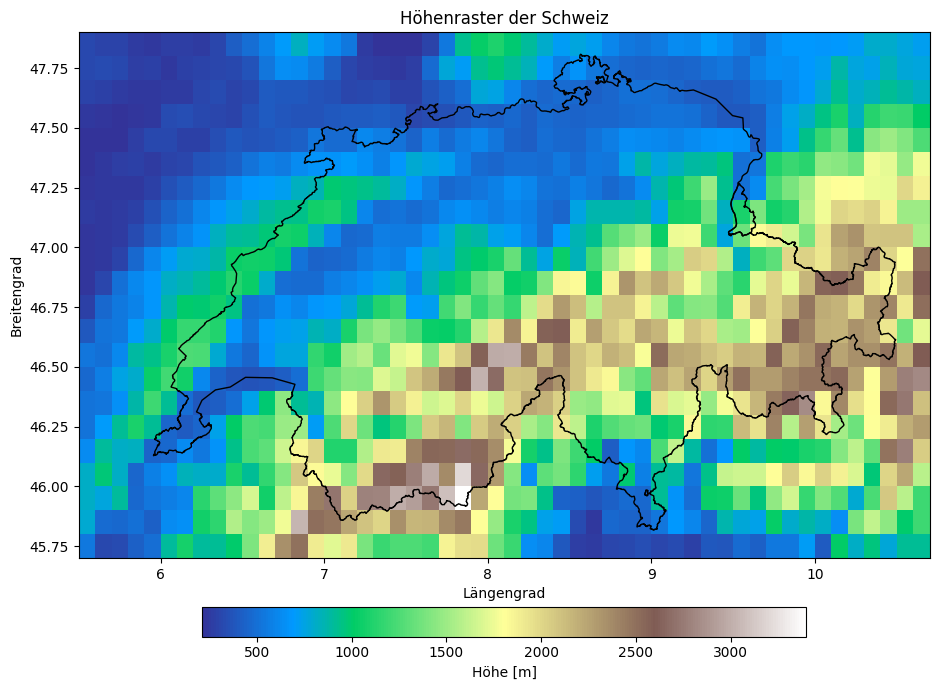

In [33]:
fig, ax = plt.subplots(figsize=(10, 7))

mappable = elevation_tg.plot(
    ax=ax,
    cmap="terrain",
    add_colorbar=False
)

schweiz.boundary.plot(
    ax=ax,
    color="black",
    linewidth=1.0,
    zorder=20
)

cbar = fig.colorbar(
    mappable,
    ax=ax,
    orientation="horizontal",
    pad=0.08,
    fraction=0.05
)
cbar.set_label("Höhe [m]")

mean_lat = float(elevation_tg.latitude.mean())
ax.set_aspect(1 / np.cos(np.deg2rad(mean_lat))) #Kompensiert Verzerrung der Längengrade. Die x-Achse wird gestreckt für die korrekten Proportionen

ax.set_title("Höhenraster der Schweiz")
ax.set_xlabel("Längengrad")
ax.set_ylabel("Breitengrad")

plt.tight_layout()
plt.show()

## 5. Datenexploration

In [34]:
tg_ch = ds_tg_ch["tg"]
print(tg_ch)

<xarray.DataArray 'tg' (time: 25171, latitude: 22, longitude: 52)> Size: 115MB
[28795624 values with dtype=float32]
Coordinates:
  * time       (time) datetime64[ns] 201kB 1950-01-01 1950-01-02 ... 2018-11-30
  * latitude   (latitude) float64 176B 45.75 45.85 45.95 ... 47.65 47.75 47.85
  * longitude  (longitude) float64 416B 5.55 5.65 5.75 ... 10.45 10.55 10.65
Attributes:
    standard_name:  air_temperature
    long_name:      mean temperature
    units:          Celsius


In [35]:
if DO_EXPORT:
    tg_ch.to_netcdf(EXPORT_DIR/"tg_ch.nc")

### 5.1 Temperaturverteilung

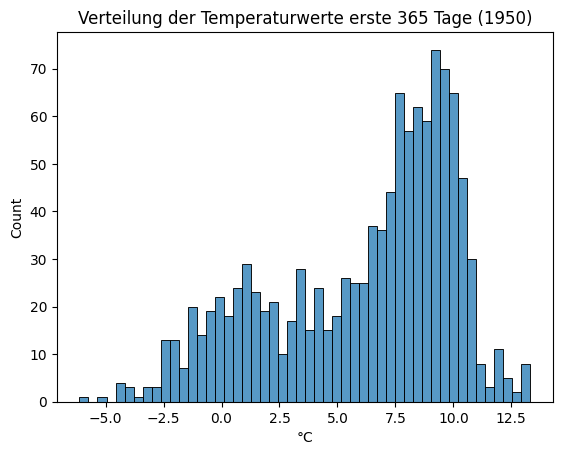

In [36]:
sample = tg_ch.isel(time=slice(0,365)).mean(dim="time")

sns.histplot(sample.values.flatten(), bins=50)
plt.title("Verteilung der Temperaturwerte erste 365 Tage (1950)")
plt.xlabel("°C")
plt.show()

### 5.2 Temperatur-Muster nach Höhenstufen

### Beispieltag 15. Juli 2018

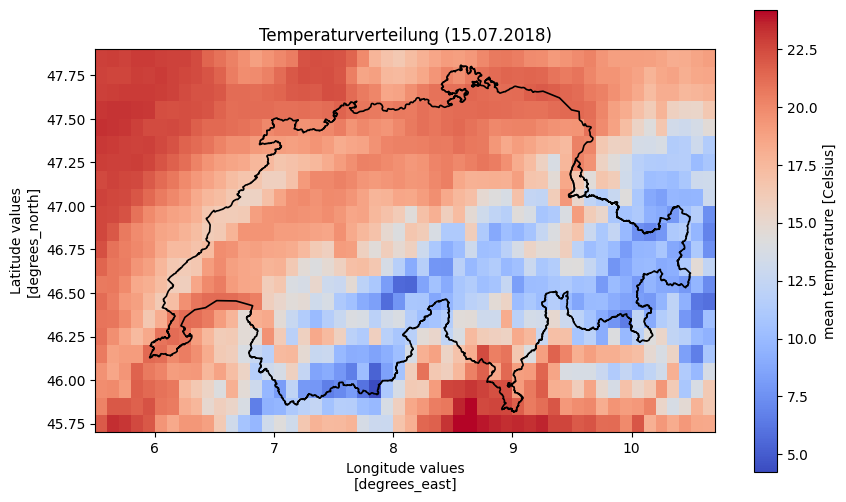

In [37]:
#Beispieltag 15. Juli 2018
fig, ax = plt.subplots(figsize=(10,6))

tg_ch.sel(time="2018-07-15").plot(
    ax=ax,
    cmap="coolwarm"
)

schweiz.boundary.plot(
    ax=ax,
    color="black",
    linewidth=1.2,
    zorder=10
)

# Aspect fix (nur bei lat/lon)
mean_lat = float(tg_ch.latitude.mean())
ax.set_aspect(1 / np.cos(np.deg2rad(mean_lat)))

ax.set_title("Temperaturverteilung (15.07.2018)")
plt.show()

### Beispieltag 3. Dezember 2015

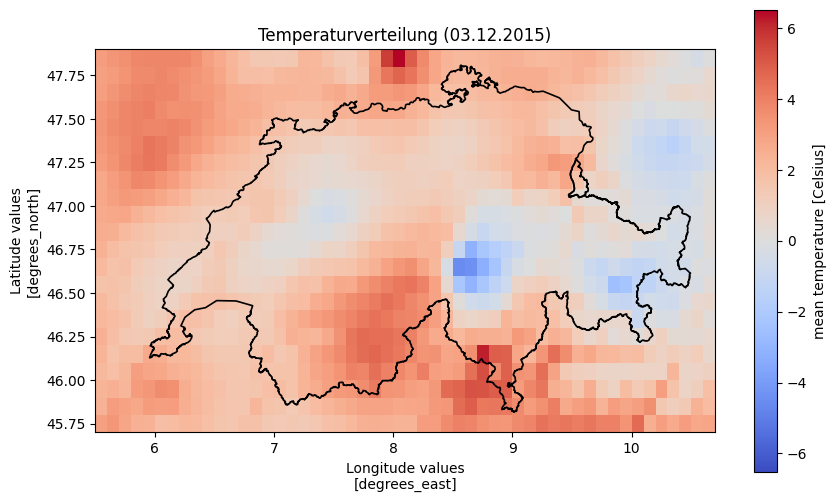

In [38]:
#Beispieltag 3. Dezember 2015
fig, ax = plt.subplots(figsize=(10,6))

tg_ch.sel(time="2015-12-03").plot(
    ax=ax,
    cmap="coolwarm"
)

schweiz.boundary.plot(
    ax=ax,
    color="black",
    linewidth=1.2,
    zorder=10
)

# Aspect fix (nur bei lat/lon)
mean_lat = float(tg_ch.latitude.mean())
ax.set_aspect(1 / np.cos(np.deg2rad(mean_lat)))

ax.set_title("Temperaturverteilung (03.12.2015)")
plt.show()

### 5.4 Temperaturgradient

#### 5.4.1 Beispieltage 2003-08-08 "Hitzesommer" und 2010-01-05

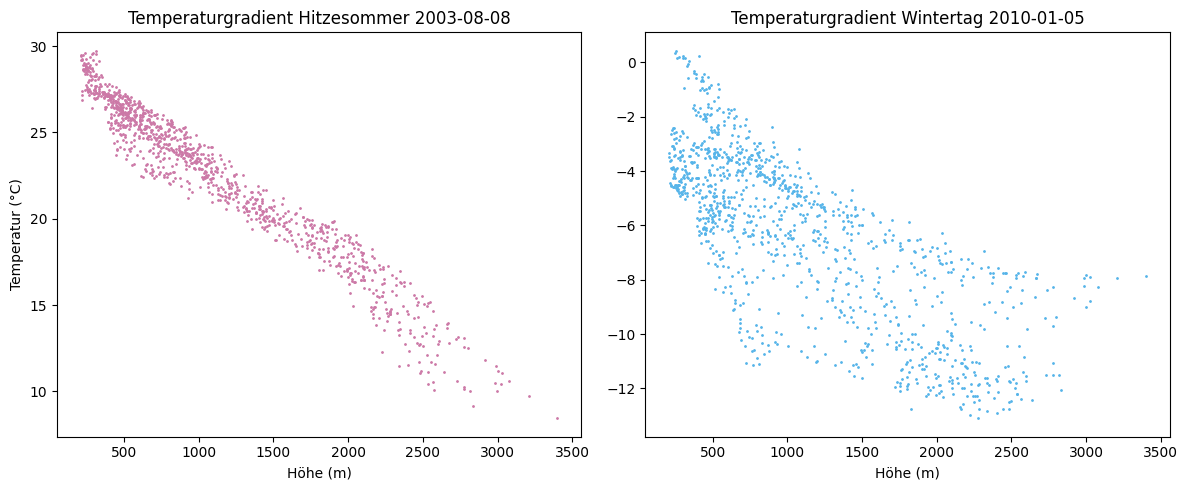

In [39]:
fig, axes = plt.subplots(1, 2, figsize=(12,5))

# Tag 1
temp1 = tg_ch.sel(time="2003-08-08")

axes[0].scatter(
    elevation_tg.values.flatten(),
    temp1.values.flatten(),
    s=1,
    color=SUMMER_COLOR,
)

axes[0].set_title("Temperaturgradient Hitzesommer 2003-08-08")
axes[0].set_xlabel("Höhe (m)")
axes[0].set_ylabel("Temperatur (°C)")


# Tag 2
temp2 = tg_ch.sel(time="2010-01-05")

axes[1].scatter(
    elevation_tg.values.flatten(),
    temp2.values.flatten(),
    s=1,
    color=WINTER_COLOR,
)

axes[1].set_title("Temperaturgradient Wintertag 2010-01-05")
axes[1].set_xlabel("Höhe (m)")

plt.tight_layout()
plt.show()

Sommer:
- klassischer troposphärischer Temperaturgradient ≈−6.5°C/1000m
- stabile Sommerlage
- gute vertikale Durchmischung

Winter:
- flacher, teilweise umgekehrter Gradient (Temperaturinversionen)
- kalte Luft mit Hochnebel-Deckel sammelt sich im Mittelland
- in der Höhe wärmere Luft

#### 5.4.2 Export Temperaturgradient für Dashboard

In [40]:
inversion_summer_df = pd.DataFrame({
    "elevation": elevation_tg.values.flatten(),
    "temperature": temp1.values.flatten(),
})

inversion_winter_df = pd.DataFrame({
    "elevation": elevation_tg.values.flatten(),
    "temperature": temp2.values.flatten(),
})

if DO_EXPORT:
    inversion_summer_df.to_csv(
        EXPORT_DIR / "inversion_summer_2003-08-08.csv",
        index=False
    )

    inversion_winter_df.to_csv(
        EXPORT_DIR / "inversion_winter_2010-01-05.csv",
        index=False
    )

#### 5.4.3 Weitere Exploration Temperaturgradient

Die nachfolgende Exploration wurde nicht weiter verfolgt, da Erklärungsaufwand für Dashboard zu hoch gewesen wäre.

In [41]:
def compute_gradient(temp):

    elev = elevation_tg.values.flatten() #2D-Array in eine Liste umwandeln
    temp = temp.values.flatten()

    mask = ~np.isnan(temp) #nur gültige Werte behalten

    slope, intercept, r, p, se = linregress(elev[mask], temp[mask]) #slope (Steigung der Regressionsgeraden) ist der Temperaturgradient

    return slope

In [42]:
#Gradient pro Tag berechnen
gradients = []

for t in tg_ch.time.values:

    temp = tg_ch.sel(time=t)

    g = compute_gradient(temp)

    gradients.append(g)

In [43]:
#Nach Monat gruppieren
df_grad = pd.DataFrame({
    "time": tg_ch.time.values,
    "gradient": gradients
})

df_grad["month"] = pd.to_datetime(df_grad["time"]).dt.month

Text(0.5, 1.0, 'Temperaturgradient nach Monat')

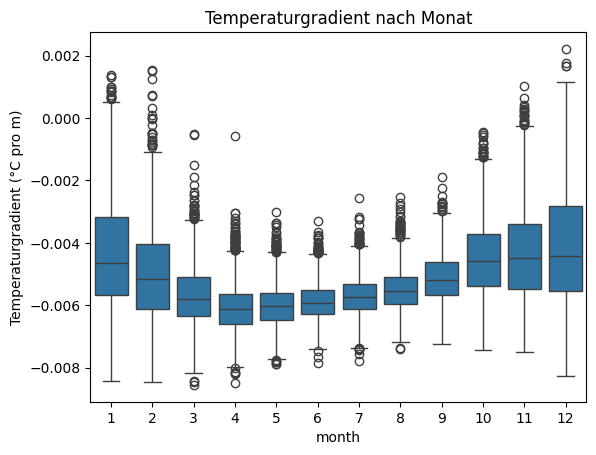

In [44]:
sns.boxplot(
    x="month",
    y="gradient",
    data=df_grad
)

plt.ylabel("Temperaturgradient (°C pro m)")
plt.title("Temperaturgradient nach Monat")

Temperaturänderung pro Höhenmeter:
z.B. -0.006: Temperatur sinkt um ~6 °C pro 1000 m
Positiver Gradient bedeutet Inversionslage (Hochnebellage)
Stark negativer Gradient bedeutet stabile, gut durchmischte Atmosphäre

## 6. Analyse der Daten

### 6.1 Zusätzliche Temperaturvariable Max setzen und Zonen prüfen

In [45]:
print(tg_ch.latitude.equals(zone_tg.latitude))
print(tg_ch.longitude.equals(zone_tg.longitude))

True
True


In [46]:
tx_ch = ds_tx_ch["tx"]

print(tx_ch.latitude.equals(zone_tx.latitude))
print(tx_ch.longitude.equals(zone_tx.longitude))

True
True


In [47]:
if DO_EXPORT:
    tx_ch.to_netcdf(EXPORT_DIR/"tx_ch.nc")

In [48]:
#Tägliches Temperaturmittel pro Zone
tg_mittelland = tg_ch.where(zone_tg == 1).mean(dim=("latitude","longitude"))
tg_voralpen = tg_ch.where(zone_tg == 2).mean(dim=("latitude","longitude"))
tg_hochgebirge = tg_ch.where(zone_tg == 3).mean(dim=("latitude","longitude"))

print(tg_mittelland)

<xarray.DataArray 'tg' (time: 25171)> Size: 101kB
array([-2.1328182, -0.6512273,  1.785409 , ...,  3.048159 ,  4.663886 ,
        4.77375  ], shape=(25171,), dtype=float32)
Coordinates:
  * time     (time) datetime64[ns] 201kB 1950-01-01 1950-01-02 ... 2018-11-30
Attributes:
    standard_name:  air_temperature
    long_name:      mean temperature
    units:          Celsius


### 6.2 Jährlicher Temperatur-Mittelwert berechnen

In [49]:
tg_yearly = tg_ch.groupby("time.year").mean()

In [50]:
tg_mittelland_y = tg_yearly.where(zone_tg == 1).mean(dim=("latitude","longitude"))
tg_voralpen_y = tg_yearly.where(zone_tg == 2).mean(dim=("latitude","longitude"))
tg_hochgebirge_y = tg_yearly.where(zone_tg == 3).mean(dim=("latitude","longitude"))

tg_mittelland_std = tg_yearly.where(zone_tg == 1).std(dim=("latitude", "longitude"))
tg_voralpen_std = tg_yearly.where(zone_tg == 2).std(dim=("latitude", "longitude"))
tg_hochgebirge_std = tg_yearly.where(zone_tg == 3).std(dim=("latitude", "longitude"))

In [51]:
mean_m = tg_mittelland_y
std_m = tg_mittelland_std

mean_v = tg_voralpen_y
std_v = tg_voralpen_std

mean_h = tg_hochgebirge_y
std_h = tg_hochgebirge_std

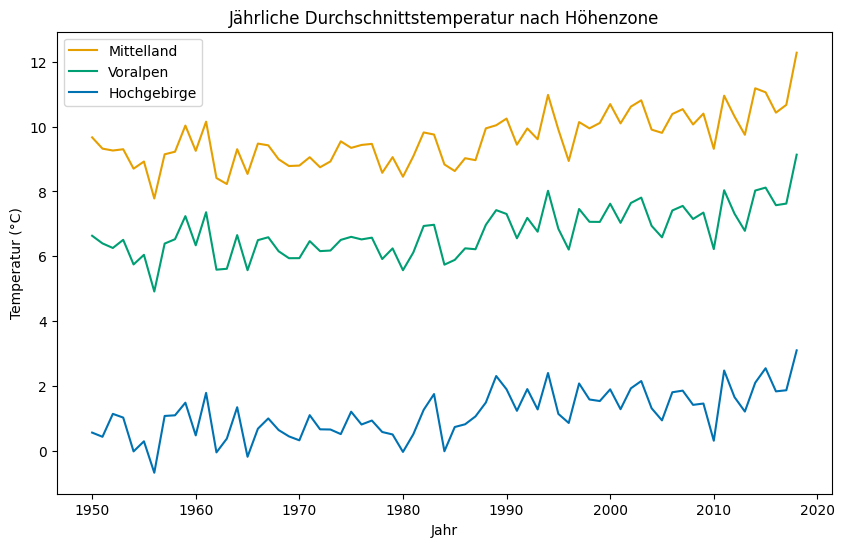

In [52]:
plt.figure(figsize=(10,6))

plt.plot(tg_mittelland_y.year, tg_mittelland_y, color=ZONEN_FARBEN["Mittelland"], label="Mittelland")
plt.plot(tg_voralpen_y.year, tg_voralpen_y, color=ZONEN_FARBEN["Voralpen"], label="Voralpen")
plt.plot(tg_hochgebirge_y.year, tg_hochgebirge_y, color=ZONEN_FARBEN["Hochgebirge"], label="Hochgebirge")

plt.legend()
plt.title("Jährliche Durchschnittstemperatur nach Höhenzone")
plt.xlabel("Jahr")
plt.ylabel("Temperatur (°C)")

plt.show()

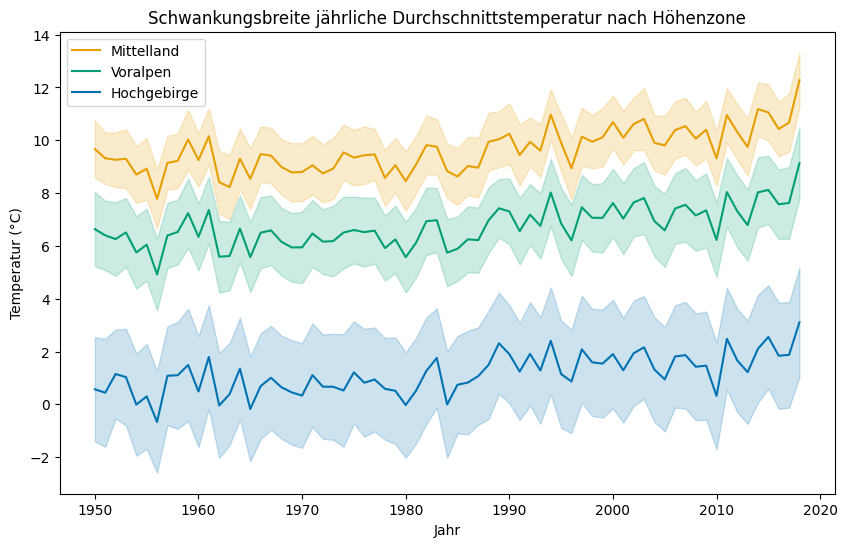

In [53]:
plt.figure(figsize=(10,6))

# Mittelland
plt.plot(mean_m.year, mean_m, color=ZONEN_FARBEN["Mittelland"], label="Mittelland")
plt.fill_between(
    mean_m.year,
    mean_m - std_m,
    mean_m + std_m,
    color=ZONEN_FARBEN["Mittelland"],
    alpha=0.2
)

# Voralpen
plt.plot(mean_v.year, mean_v, color=ZONEN_FARBEN["Voralpen"], label="Voralpen")
plt.fill_between(
    mean_v.year,
    mean_v - std_v,
    mean_v + std_v,
    color=ZONEN_FARBEN["Voralpen"],
    alpha=0.2
)

# Hochgebirge
plt.plot(mean_h.year, mean_h, color=ZONEN_FARBEN["Hochgebirge"], label="Hochgebirge")
plt.fill_between(
    mean_h.year,
    mean_h - std_h,
    mean_h + std_h,
    color=ZONEN_FARBEN["Hochgebirge"],
    alpha=0.2
)

plt.legend()
plt.title("Schwankungsbreite jährliche Durchschnittstemperatur nach Höhenzone")
plt.xlabel("Jahr")
plt.ylabel("Temperatur (°C)")

plt.show()

### 6.3 Monatsmittel der Erwärmung pro Dekade und Höhenzone

#### 6.3.1 Vorbereitung der Daten seasonal trends

In [54]:
#Monat und Jahr extrahieren
df = xr.Dataset({
    "Mittelland": tg_mittelland,
    "Voralpen": tg_voralpen,
    "Hochgebirge": tg_hochgebirge
}).to_dataframe().reset_index()

df["year"] = pd.to_datetime(df["time"]).dt.year
df["month"] = pd.to_datetime(df["time"]).dt.month

In [55]:
#Monatsmittel pro Jahr
monthly = df.groupby(["year","month"]).mean().reset_index()

In [56]:
#Trend pro Monat mit linearer Regression
months = range(1,13)

trend_mittelland = []
trend_voralpen = []
trend_hochgebirge = []

for m in months:

    sub = monthly[monthly["month"] == m]

    slope_m = linregress(sub["year"], sub["Mittelland"]).slope
    slope_v = linregress(sub["year"], sub["Voralpen"]).slope
    slope_h = linregress(sub["year"], sub["Hochgebirge"]).slope

    trend_mittelland.append(slope_m)
    trend_voralpen.append(slope_v)
    trend_hochgebirge.append(slope_h)

In [57]:
#Skalierung von Jahr auf Jahrzehnt für verständlichere Y-Werte
trend_mittelland = np.array(trend_mittelland) * 10
trend_voralpen = np.array(trend_voralpen) * 10
trend_hochgebirge = np.array(trend_hochgebirge) * 10

In [58]:
months = ["Jan", "Feb", "Mrz", "Apr", "Mai", "Jun",
          "Jul", "Aug", "Sep", "Okt", "Nov", "Dez"]

heatmap_data = pd.DataFrame(
    [
        trend_mittelland,
        trend_voralpen,
        trend_hochgebirge
    ],
    index=["Mittelland", "Voralpen", "Hochgebirge"],
    columns=months
)

print(heatmap_data)

                  Jan       Feb       Mrz       Apr       Mai       Jun  \
Mittelland   0.343050  0.181395  0.251324  0.324484  0.274658  0.341433   
Voralpen     0.284208  0.139654  0.257614  0.333860  0.261370  0.330440   
Hochgebirge  0.272199  0.116087  0.220231  0.321077  0.270745  0.337059   

                  Jul       Aug       Sep       Okt       Nov       Dez  
Mittelland   0.305826  0.388535  0.118352  0.276008  0.229826  0.225511  
Voralpen     0.267753  0.355405  0.074419  0.228583  0.190517  0.172137  
Hochgebirge  0.265243  0.359719  0.066603  0.186785  0.169330  0.154266  


#### 6.3.2 Visualisierung seasonal trends mit Heatmap

Die nachfolgende Heat-Map wurde nicht in das Dashboard übernommen, da diese Darstellung für non-experts womöglich zu ungewohnt ist.

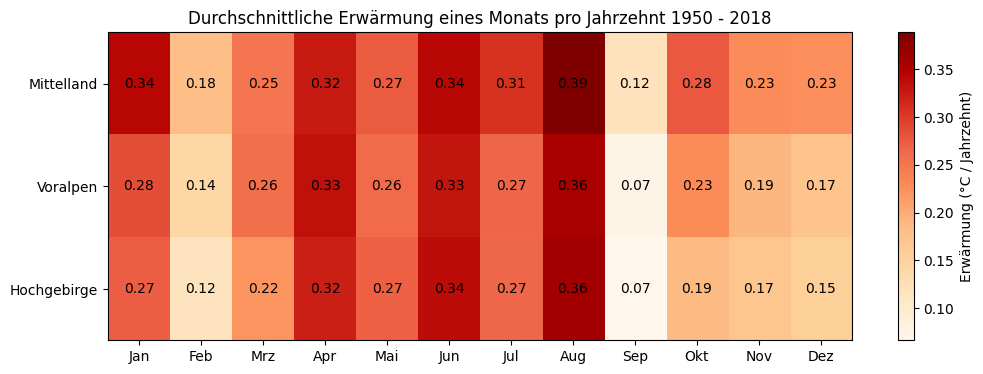

In [111]:
plt.figure(figsize=(12, 4))

im = plt.imshow(heatmap_data, aspect="auto", cmap="OrRd")

plt.xticks(ticks=np.arange(len(months)), labels=months)
plt.yticks(ticks=np.arange(len(heatmap_data.index)), labels=heatmap_data.index)

for i in range(heatmap_data.shape[0]):
    for j in range(heatmap_data.shape[1]):
        value = heatmap_data.iloc[i, j]
        plt.text(j, i, f"{value:.2f}", ha="center", va="center", color="black")

plt.colorbar(im, label="Erwärmung (°C / Jahrzehnt)")
plt.title("Durchschnittliche Erwärmung eines Monats pro Jahrzehnt 1950 - 2018")

plt.show()

Die Werte zeigen, um wie viele Grad sich ein Monat seit 1950 pro Jahrzehnt im Durchschnitt erwärmt hat.

#### 6.3.3 Visualisierung seasonal trends mit line plot

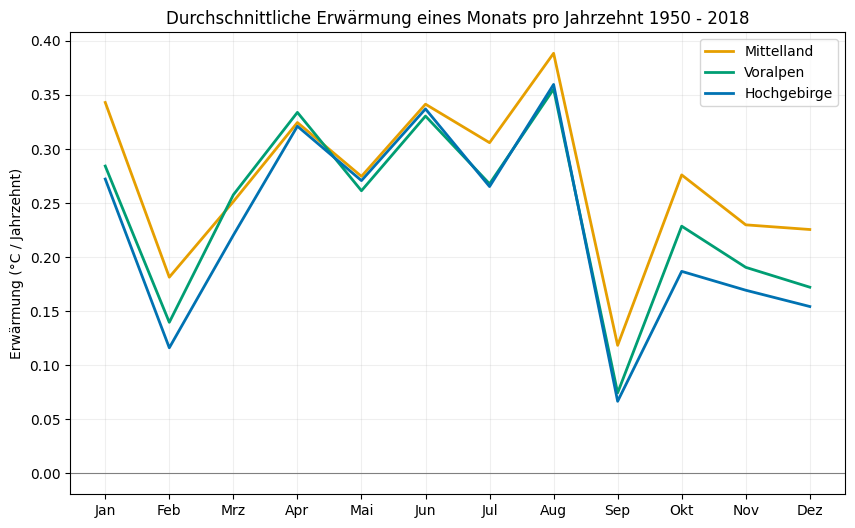

In [60]:
months = ["Jan","Feb","Mrz","Apr","Mai","Jun",
          "Jul","Aug","Sep","Okt","Nov","Dez"]

plt.figure(figsize=(10,6))

plt.plot(months, trend_mittelland, color=ZONEN_FARBEN["Mittelland"], linewidth=2, label="Mittelland")
plt.plot(months, trend_voralpen, color=ZONEN_FARBEN["Voralpen"], linewidth=2, label="Voralpen")
plt.plot(months, trend_hochgebirge, color=ZONEN_FARBEN["Hochgebirge"], linewidth=2, label="Hochgebirge")

plt.axhline(0, color="grey", linewidth=0.8)

plt.ylabel("Erwärmung (°C / Jahrzehnt)")
plt.title("Durchschnittliche Erwärmung eines Monats pro Jahrzehnt 1950 - 2018")

plt.legend()
plt.grid(alpha=0.2)

plt.show()

#### 6.3.4 Export für Dashboard seasonal trends

In [61]:
df_trends = pd.DataFrame({
    "month": months,
    "Mittelland": trend_mittelland,
    "Voralpen": trend_voralpen,
    "Hochgebirge": trend_hochgebirge,
})

if DO_EXPORT:
    df_trends.rename(columns=ZONEN_EXPORT_NAMEN).to_csv(
        EXPORT_DIR / "monthly_warming_trends.csv",
        index=False
    )

#### 6.3.5 Seasonal Trends Barchart

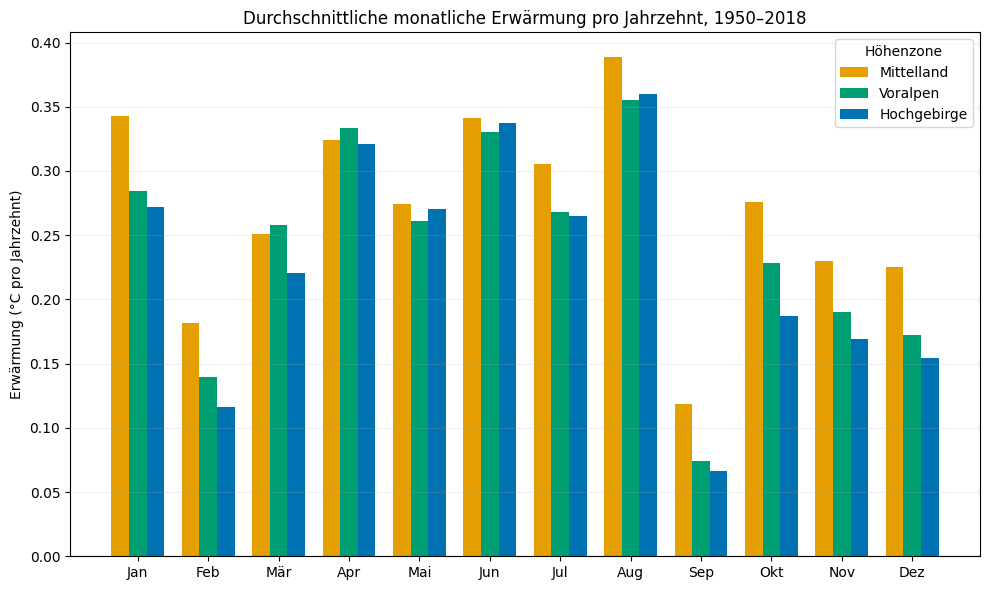

In [98]:
months = ["Jan", "Feb", "Mär", "Apr", "Mai", "Jun",
          "Jul", "Aug", "Sep", "Okt", "Nov", "Dez"]

x = np.arange(len(months))
width = 0.25

plt.figure(figsize=(10, 6))

plt.bar(
    x - width,
    trend_mittelland,
    width=width,
    label="Mittelland",
    color=ZONEN_FARBEN["Mittelland"],
)

plt.bar(
    x,
    trend_voralpen,
    width=width,
    label="Voralpen",
    color=ZONEN_FARBEN["Voralpen"],
)

plt.bar(
    x + width,
    trend_hochgebirge,
    width=width,
    label="Hochgebirge",
    color=ZONEN_FARBEN["Hochgebirge"],
)

plt.axhline(0, color="grey", linewidth=0.8)

plt.xticks(x, months)
plt.ylabel("Erwärmung (°C pro Jahrzehnt)")
plt.title("Durchschnittliche monatliche Erwärmung pro Jahrzehnt, 1950–2018")

plt.legend(title="Höhenzone")
plt.grid(axis="y", alpha=0.2)

plt.tight_layout()
plt.show()

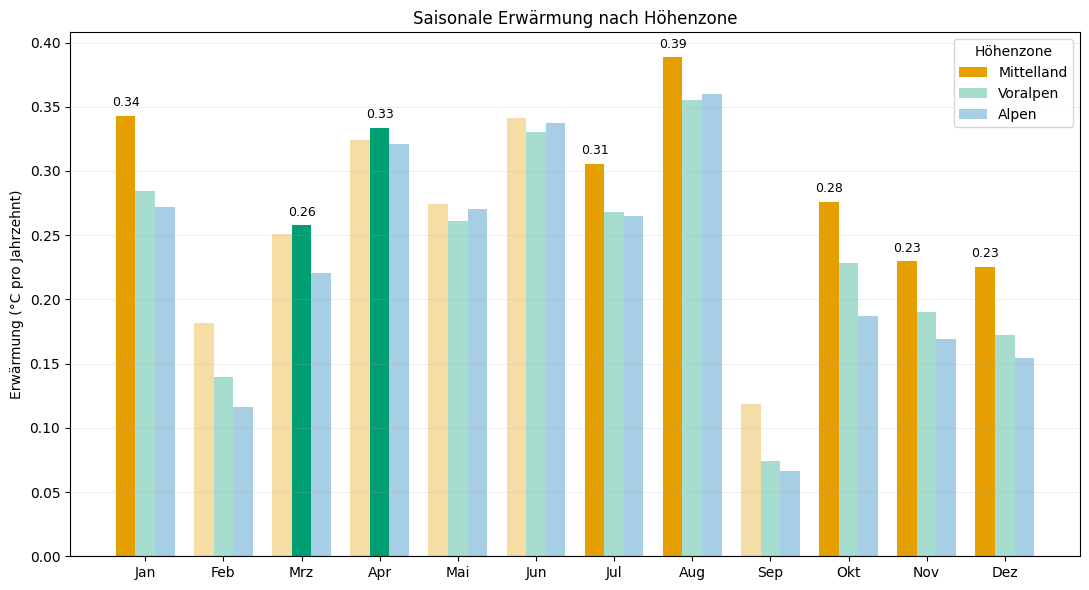

In [100]:
from matplotlib.colors import to_rgb

months = ["Jan", "Feb", "Mrz", "Apr", "Mai", "Jun",
          "Jul", "Aug", "Sep", "Okt", "Nov", "Dez"]

x = np.arange(len(months))
width = 0.25

def lighten(color, amount=0.65):
    """
    Mischt die Farbe mit Weiss.
    amount=0 -> Originalfarbe
    amount=1 -> Weiss
    """
    rgb = np.array(to_rgb(color))
    return tuple(rgb + (1 - rgb) * amount)

# Basisfarben
c_mittelland = ZONEN_FARBEN["Mittelland"]
c_voralpen = ZONEN_FARBEN["Voralpen"]
c_hochgebirge = ZONEN_FARBEN["Hochgebirge"]

# Blasse Varianten
c_mittelland_light = lighten(c_mittelland, 0.65)
c_voralpen_light = lighten(c_voralpen, 0.65)
c_hochgebirge_light = lighten(c_hochgebirge, 0.65)

# Welche Monate sollen betont werden?
# Index: Jan=0, Feb=1, Mrz=2, Apr=3, ...
highlight_mittelland = {0, 6, 7, 9, 10, 11}   # Jan, Jul, Aug, Okt, Nov, Dez
highlight_voralpen   = {2, 3}                 # Mrz, Apr
highlight_hochgebirge = set()                 # nichts speziell hervorheben

# Farbvektoren pro Balken
colors_mittelland = [
    c_mittelland if i in highlight_mittelland else c_mittelland_light
    for i in range(12)
]

colors_voralpen = [
    c_voralpen if i in highlight_voralpen else c_voralpen_light
    for i in range(12)
]

colors_hochgebirge = [
    c_hochgebirge if i in highlight_hochgebirge else c_hochgebirge_light
    for i in range(12)
]

fig, ax = plt.subplots(figsize=(11, 6))

bars1 = ax.bar(
    x - width,
    trend_mittelland,
    width=width,
    label="Mittelland",
    color=colors_mittelland,
    edgecolor="none"
)

bars2 = ax.bar(
    x,
    trend_voralpen,
    width=width,
    label="Voralpen",
    color=colors_voralpen,
    edgecolor="none"
)

bars3 = ax.bar(
    x + width,
    trend_hochgebirge,
    width=width,
    label="Alpen",
    color=colors_hochgebirge,
    edgecolor="none"
)

ax.axhline(0, color="grey", linewidth=0.8)
ax.set_xticks(x)
ax.set_xticklabels(months)
ax.set_ylabel("Erwärmung (°C pro Jahrzehnt)")
ax.set_title("Saisonale Erwärmung nach Höhenzone")
ax.legend(title="Höhenzone")
ax.grid(axis="y", alpha=0.2)

# Optional: Nur hervorgehobene Balken beschriften
def annotate_selected(bars, highlight_idx):
    for i, bar in enumerate(bars):
        if i in highlight_idx:
            h = bar.get_height()
            ax.text(
                bar.get_x() + bar.get_width()/2,
                h + 0.005,
                f"{h:.2f}",
                ha="center",
                va="bottom",
                fontsize=9
            )

annotate_selected(bars1, highlight_mittelland)
annotate_selected(bars2, highlight_voralpen)
annotate_selected(bars3, highlight_hochgebirge)

plt.tight_layout()
plt.show()

### 6.4 Growing Degree Days

#### 6.4.1 Vorbereitung der Daten für GDD

In [62]:
#Minimale Temperatur für Pflanzenwachstum
T_base = 5

In [63]:
#GDD pro Tag berechnen
gdd_daily = xr.where(tg_ch > T_base, tg_ch - T_base, 0)
print(gdd_daily)

<xarray.DataArray 'tg' (time: 25171, latitude: 22, longitude: 52)> Size: 115MB
array([[[0.        , 0.        , 0.        , ..., 0.        ,
         0.        , 0.        ],
        [0.        , 0.        , 0.        , ..., 0.        ,
         0.        , 0.        ],
        [0.        , 0.        , 0.        , ..., 0.        ,
         0.        , 0.        ],
        ...,
        [0.        , 0.        , 0.        , ..., 0.        ,
         0.        , 0.        ],
        [0.        , 0.        , 0.        , ..., 0.        ,
         0.        , 0.        ],
        [0.        , 0.        , 0.        , ..., 0.        ,
         0.        , 0.        ]],

       [[0.        , 0.        , 0.        , ..., 0.        ,
         0.        , 0.        ],
        [0.        , 0.        , 0.        , ..., 0.        ,
         0.        , 0.        ],
        [0.        , 0.        , 0.        , ..., 0.        ,
         0.        , 0.        ],
...
        [2.3899999 , 2.5       , 2.6  

In [64]:
#GDD pro Jahr berechnen
gdd_year = gdd_daily.groupby("time.year").sum(dim="time")

In [65]:
#Mittelwert pro Höhenzone
gdd_mittelland = gdd_year.where(zone_tg == 1).mean(dim=("latitude","longitude"))
gdd_voralpen = gdd_year.where(zone_tg == 2).mean(dim=("latitude","longitude"))
gdd_hochgebirge = gdd_year.where(zone_tg == 3).mean(dim=("latitude","longitude"))

#### 6.4.2 Visualisierung GDD nach Höhenzone

Diese Visualisierung wurde nicht übernommen, da die totale Jahressumme denselben Trend anzeigt wie die Temperaturmittel.

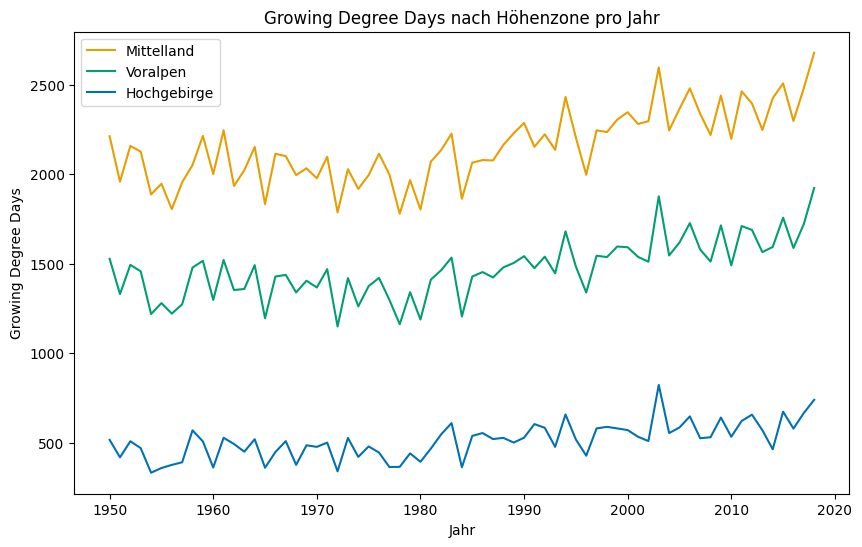

In [66]:
plt.figure(figsize=(10,6))

plt.plot(gdd_mittelland.year, gdd_mittelland, color=ZONEN_FARBEN["Mittelland"], label="Mittelland")
plt.plot(gdd_voralpen.year, gdd_voralpen, color=ZONEN_FARBEN["Voralpen"], label="Voralpen")
plt.plot(gdd_hochgebirge.year, gdd_hochgebirge, color=ZONEN_FARBEN["Hochgebirge"], label="Hochgebirge")

plt.ylabel("Growing Degree Days")
plt.xlabel("Jahr")
plt.title("Growing Degree Days nach Höhenzone pro Jahr")

plt.legend()
plt.show()

Growing Degree Days (GDD) messen die Wärmemenge, die Pflanzen während eines Jahres zur Verfügung steht. Ein Wert von 2500 bedeutet, dass sich im Laufe des Jahres eine Temperatursumme von 2500 Grad über der Wachstumsschwelle von 5 °C angesammelt hat.

Mehr GDD bedeutet:
-längere Vegetationsperiode
-schnelleres Wachstum
-neue Kulturen möglich


Der Anstieg der Growing Degree Days spiegelt die allgemeine Erwärmung wider und zeigt, dass sich die potenzielle Vegetationsperiode verlängert.

#### 6.4.3 Datum des Erreichens eines GDD-Schwellenwerts

Anstatt nur die jährliche Gesamtsumme der Growing Degree Days zu betrachten, untersucht die folgende Analyse, zu welchem Zeitpunkt im Jahr ein biologisch relevanter Wärmeschwellenwert erreicht wird.

Als explorativer Indikator wurde ein Schwellenwert von 300 GDD gewählt, der in etwa mit der Blütezeit von Obstbäumen wie Apfelbäumen zusammenhängt. Frühere Schwellendaten können auf eine frühere Vegetationsentwicklung infolge steigender Frühlingstemperaturen hinweisen.

In [67]:
#Kumulierte GDD innerhalb jedes Jahres
gdd_kumuliert = gdd_daily.groupby("time.year").cumsum(dim="time")

In [68]:
GDD_SCHWELLE = 300

In [69]:
def erstes_schwellen_datum(gdd_kumuliert_zone, schwelle):

    years = []
    doy_values = []

    for year in np.unique(gdd_kumuliert_zone["time"].dt.year.values):

        yearly_data = gdd_kumuliert_zone.sel(
            time=gdd_kumuliert_zone["time"].dt.year == year
        )

        reached = yearly_data >= schwelle

        if reached.any().item():

            first_time = yearly_data["time"].where(reached, drop=True)[0]

            years.append(int(year))
            doy_values.append(int(first_time.dt.dayofyear.item()))

    return pd.DataFrame({
        "year": years,
        "day_of_year": doy_values
    })

In [70]:
gdd_kumuliert_mittelland = (
    gdd_kumuliert
    .where(zone_tg == 1)
    .mean(dim=("latitude", "longitude"))
)

gdd_kumuliert_voralpen = (
    gdd_kumuliert
    .where(zone_tg == 2)
    .mean(dim=("latitude", "longitude"))
)

gdd_kumuliert_hochgebirge = (
    gdd_kumuliert
    .where(zone_tg == 3)
    .mean(dim=("latitude", "longitude"))
)

In [71]:
df_mittelland = erstes_schwellen_datum(
    gdd_kumuliert_mittelland,
    GDD_SCHWELLE
)
df_mittelland["zone"] = "Mittelland"

df_voralpen = erstes_schwellen_datum(
    gdd_kumuliert_voralpen,
    GDD_SCHWELLE
)
df_voralpen["zone"] = "Voralpen"

df_hochgebirge = erstes_schwellen_datum(
    gdd_kumuliert_hochgebirge,
    GDD_SCHWELLE
)
df_hochgebirge["zone"] = "Hochgebirge"

In [72]:
gdd_schwelle_df = pd.concat([
    df_mittelland,
    df_voralpen,
    df_hochgebirge
])

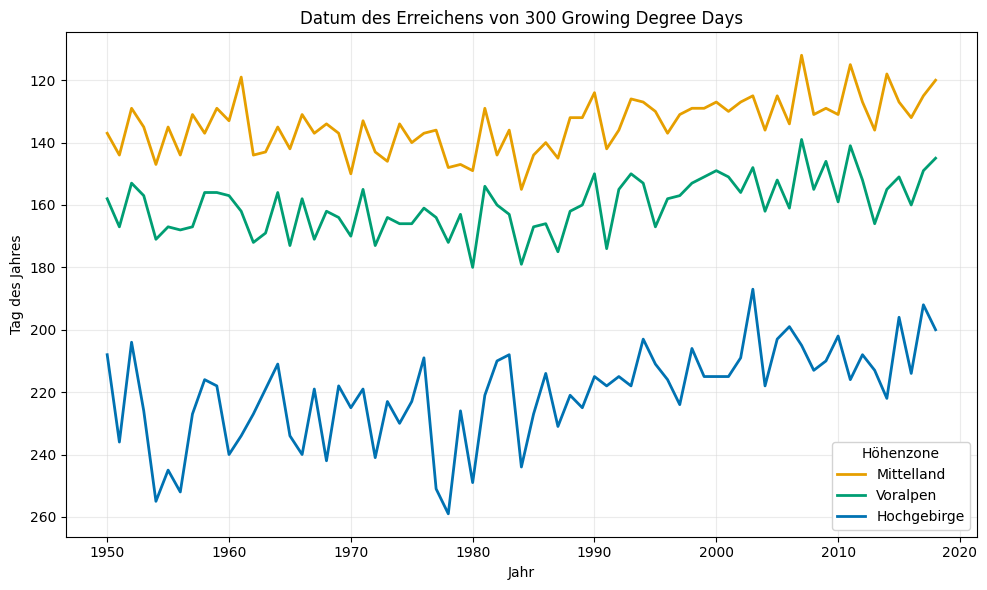

In [73]:
fig, ax = plt.subplots(figsize=(10, 6))

sns.lineplot(
    data=gdd_schwelle_df,
    x="year",
    y="day_of_year",
    hue="zone",
    hue_order=ZONEN_REIHENFOLGE,
    palette=ZONEN_FARBEN,
    linewidth=2,
    ax=ax
)

ax.invert_yaxis()

ax.set_title("Datum des Erreichens von 300 Growing Degree Days")
ax.set_xlabel("Jahr")
ax.set_ylabel("Tag des Jahres")
ax.grid(color="#D9D9D9", alpha=0.5)
ax.legend(
    title="Höhenzone",
    facecolor="white",
    edgecolor="lightgrey",
    framealpha=1
)

plt.tight_layout()
plt.show()

Die ursprüngliche Visualisierung wird verfeinert, indem ein rolling average mit einer Spannweite von 7 Jahren gewählt wurde. Dieser beruhigt die grossen Ausschläge und zeigt das frühere Erreichen des Schwellwerts deutlich an.

Die durchnummerierten Tage (ab 1. Januar) werden mit konkreten Daten ersetzt.

Die y-Achse wurde invertiert, da aufsteigende Linien besser mit einem früheren Vegetationsbeginn assoziiert werden als absteigende.

Der Schwellwert von 300 wurde gesetzt, da zu diesem "Zeitpunkt" die Ausschläge zwar gross aber dennoch im Rahmen sind.

In [74]:
gdd_schwelle_rolling_df = (
    gdd_schwelle_df
    .sort_values(["zone", "year"])
    .reset_index(drop=True)
    .copy()
)

gdd_schwelle_rolling_df["day_of_year_rolling"] = (
    gdd_schwelle_rolling_df
    .groupby("zone")["day_of_year"]
    .rolling(window=7, center=True, min_periods=1)
    .mean()
    .reset_index(level=0, drop=True)
)

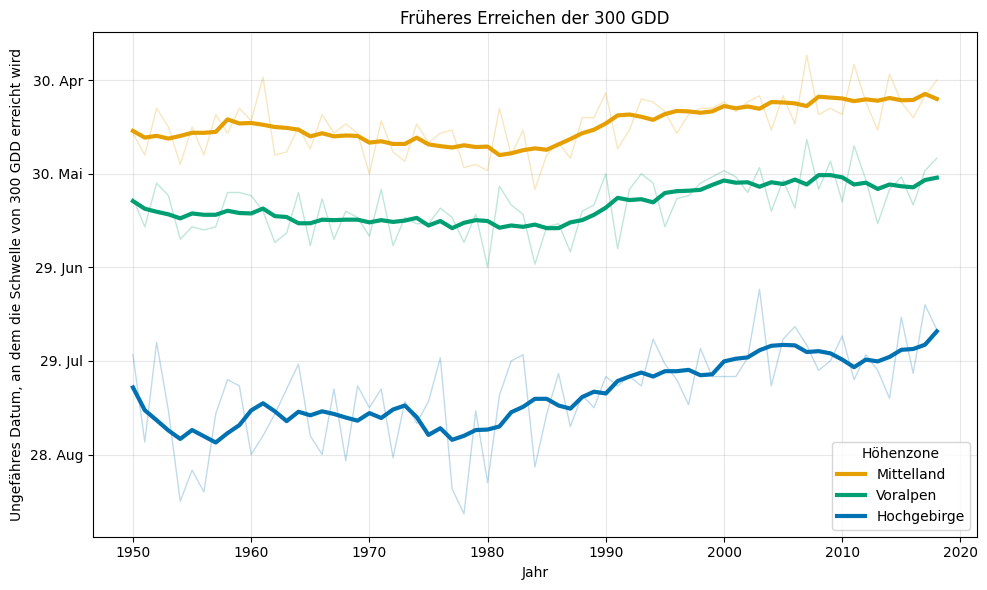

In [75]:
fig, ax = plt.subplots(figsize=(10, 6))

# Rohe Jahreswerte, schwach dargestellt
sns.lineplot(
    data=gdd_schwelle_rolling_df,
    x="year",
    y="day_of_year",
    hue="zone",
    hue_order=ZONEN_REIHENFOLGE,
    palette=ZONEN_FARBEN,
    linewidth=1,
    alpha=0.25,
    legend=False,
    ax=ax
)

# Geglättetes 7-Jahres-Mittel
sns.lineplot(
    data=gdd_schwelle_rolling_df,
    x="year",
    y="day_of_year_rolling",
    hue="zone",
    hue_order=ZONEN_REIHENFOLGE,
    palette=ZONEN_FARBEN,
    linewidth=3,
    ax=ax
)

#y-Achse für die Erklärung vorbereiten
ax.invert_yaxis()

tick_days = [120, 150, 180, 210, 240]
tick_labels = [
    "30. Apr",
    "30. Mai",
    "29. Jun",
    "29. Jul",
    "28. Aug"
]
ax.set_yticks(tick_days)
ax.set_yticklabels(tick_labels)

ax.set_title("Früheres Erreichen der 300 GDD")
ax.set_xlabel("Jahr")
ax.set_ylabel("Ungefähres Datum, an dem die Schwelle von 300 GDD erreicht wird")

ax.grid(True, alpha=0.3)
ax.legend(title="Höhenzone")

plt.tight_layout()
plt.show()

Niedrigere Werte bedeuten, dass die Schwelle früher im Jahr erreicht wird.

Nach einer relativ stabilen Phase bis in die späten 1970er-Jahre wird die GDD-Schwelle zunehmend früher im Jahr erreicht.

#### 6.4.4 Export Daten GDD für Dashboard

In [76]:
if DO_EXPORT:
    gdd_schwelle_export = gdd_schwelle_rolling_df.copy()
    gdd_schwelle_export["zone"] = gdd_schwelle_export["zone"].map(ZONEN_EXPORT_NAMEN)
    gdd_schwelle_export.to_csv(
        EXPORT_DIR / "gdd_threshold_300.csv",
        index=False
    )

### 6.5 Gegenüberstellung Durchschnittstemperatur und GDD

Die nachfolgenden Visualisierungen wurden nicht übernommen, da deren Aussagekraft zu trivial ist.

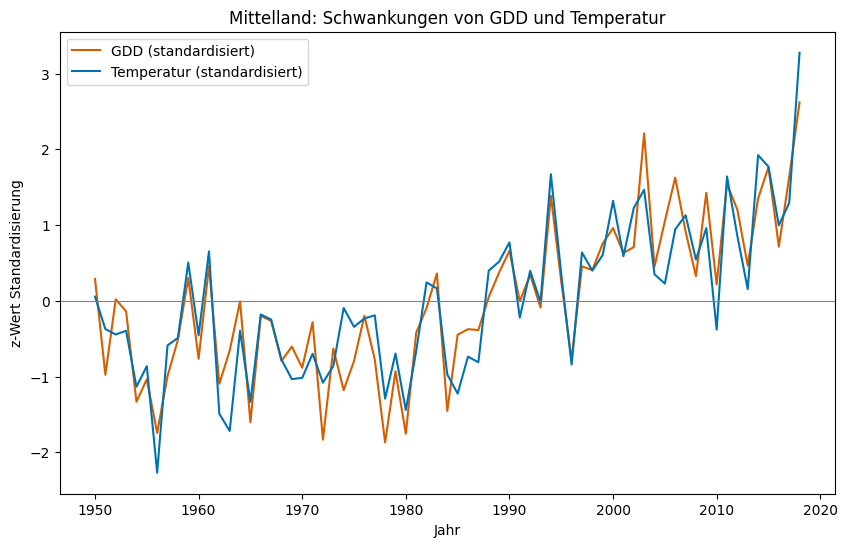

In [77]:
import matplotlib.pyplot as plt

# z-Wert Standardisierung
gdd_m_z = (gdd_mittelland - gdd_mittelland.mean()) / gdd_mittelland.std()
tg_m_z = (tg_mittelland_y - tg_mittelland_y.mean()) / tg_mittelland_y.std()

plt.figure(figsize=(10,6))

plt.plot(gdd_m_z.year, gdd_m_z, color="#D55E00", label="GDD (standardisiert)")
plt.plot(tg_m_z.year, tg_m_z, color="#0072B2", label="Temperatur (standardisiert)")

plt.axhline(0, color="grey", linewidth=0.8)
plt.title("Mittelland: Schwankungen von GDD und Temperatur")
plt.xlabel("Jahr")
plt.ylabel("z-Wert Standardisierung")
plt.legend()
plt.show()

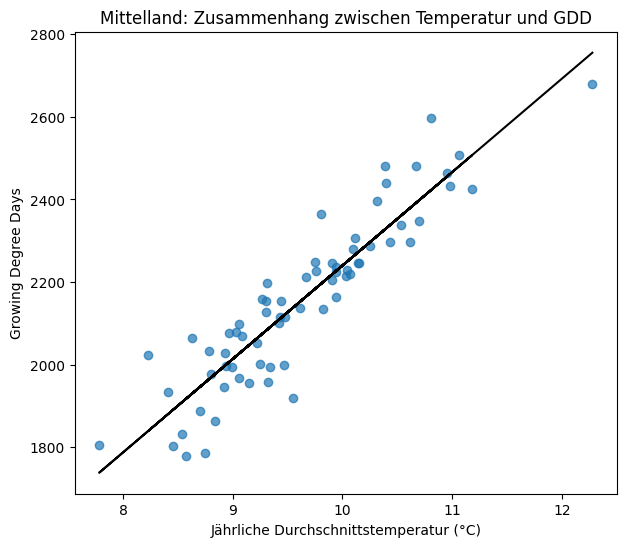

In [78]:
x = tg_mittelland_y.values
y = gdd_mittelland.values

m, b = np.polyfit(x, y, 1)

plt.figure(figsize=(7,6))
plt.scatter(x, y, alpha=0.7)
plt.plot(x, m*x + b, color="black")
plt.xlabel("Jährliche Durchschnittstemperatur (°C)")
plt.ylabel("Growing Degree Days")
plt.title("Mittelland: Zusammenhang zwischen Temperatur und GDD")
plt.show()

Korrelation von Temperatur und GDD

In [79]:
print(np.corrcoef(tg_mittelland_y.values, gdd_mittelland.values)[0,1])

0.9147054937023443


### 6.6 Hitzetage ermitteln

#### 6.6.1 Daten vorbereiten Heatdays

In [80]:
hot_days = xr.where(tx_ch >= 30, 1, 0)

In [81]:
hot_days_year = hot_days.groupby("time.year").sum(dim="time")
print(hot_days_year)

<xarray.DataArray 'tx' (year: 69, latitude: 22, longitude: 52)> Size: 631kB
array([[[15, 24, 22, ...,  6,  4,  4],
        [10, 15, 15, ...,  0,  1,  0],
        [ 9, 10,  8, ...,  0,  0,  0],
        ...,
        [12, 12, 14, ...,  0,  1,  3],
        [11, 11, 11, ...,  1,  2,  3],
        [ 9, 11, 11, ...,  2,  3,  3]],

       [[ 0,  3,  3, ...,  0,  0,  0],
        [ 0,  1,  2, ...,  0,  0,  0],
        [ 0,  0,  0, ...,  0,  0,  0],
        ...,
        [ 1,  1,  1, ...,  0,  0,  0],
        [ 1,  0,  0, ...,  0,  0,  0],
        [ 0,  0,  0, ...,  0,  0,  0]],

       [[19, 27, 25, ..., 12,  7,  7],
        [11, 20, 21, ...,  0,  7,  1],
        [10, 13,  6, ...,  0,  0,  1],
        ...,
...
        ...,
        [14, 14, 15, ...,  2,  3,  3],
        [13, 13, 14, ...,  2,  3,  4],
        [13, 14, 14, ...,  1,  2,  5]],

       [[21, 31, 28, ..., 21, 14, 13],
        [10, 24, 23, ...,  0,  7,  3],
        [10, 10,  7, ...,  0,  0,  3],
        ...,
        [22, 24, 24, ...,  1, 

In [82]:
hot_mittelland = hot_days_year.where(zone_tx == 1).mean(dim=("latitude","longitude"))
hot_voralpen = hot_days_year.where(zone_tx == 2).mean(dim=("latitude","longitude"))
hot_hochgebirge = hot_days_year.where(zone_tx == 3).mean(dim=("latitude","longitude"))
print(hot_mittelland)

<xarray.DataArray 'tx' (year: 69)> Size: 552B
array([ 9.87272727,  1.06590909, 15.27045455,  3.29545455,  2.27727273,
        0.84545455,  0.825     ,  7.21818182,  2.22045455,  4.83863636,
        0.42045455,  3.72272727,  7.70681818,  1.55909091, 11.01818182,
        2.225     ,  2.65909091,  5.67727273,  3.41590909,  3.07272727,
        2.32727273,  6.96818182,  1.06818182,  4.04090909,  4.91818182,
        5.01136364, 12.86818182,  0.37272727,  0.91818182,  1.75681818,
        2.16363636,  1.6       ,  3.44772727, 15.04772727,  6.10681818,
        4.59772727,  5.86363636,  4.14090909,  3.86818182,  4.57272727,
        8.40909091,  7.31818182, 12.99545455,  3.43181818, 15.17727273,
        8.3       ,  1.81136364,  3.08409091, 12.11363636,  3.30681818,
        5.37045455,  7.65681818,  7.93636364, 34.80909091,  5.78409091,
       13.39090909, 18.27272727,  4.52272727,  4.98636364, 10.57727273,
       12.04318182,  8.51363636, 10.65454545, 12.78181818,  6.06136364,
       27.64545455

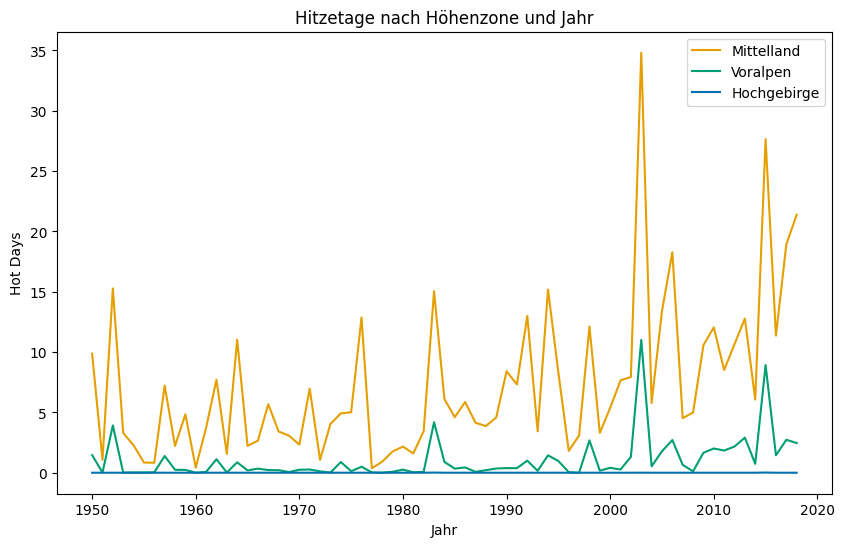

In [83]:
plt.figure(figsize=(10,6))

plt.plot(hot_mittelland.year, hot_mittelland, color=ZONEN_FARBEN["Mittelland"], label="Mittelland")
plt.plot(hot_voralpen.year, hot_voralpen, color=ZONEN_FARBEN["Voralpen"], label="Voralpen")
plt.plot(hot_hochgebirge.year, hot_hochgebirge, color=ZONEN_FARBEN["Hochgebirge"], label="Hochgebirge")

plt.ylabel("Hot Days")
plt.xlabel("Jahr")
plt.title("Hitzetage nach Höhenzone und Jahr")

plt.legend()
plt.show()

#### 6.6.2 Daten Export Heatdays für Dashboard

In [84]:
heat_days_df = pd.DataFrame({
    "year": hot_mittelland.year.values,
    "Mittelland": hot_mittelland.values,
    "Voralpen": hot_voralpen.values,
    "Hochgebirge": hot_hochgebirge.values,
})

if DO_EXPORT:
    heat_days_df.rename(columns=ZONEN_EXPORT_NAMEN).to_csv(
        EXPORT_DIR / "heat_days_by_zone.csv",
        index=False
    )

### 6.7 Gegenüberstellung Hitzetage und GDD

Die nachfolgenden Visualisierungen wurden nicht übernommen, da deren Aussagekraft zu trivial ist.

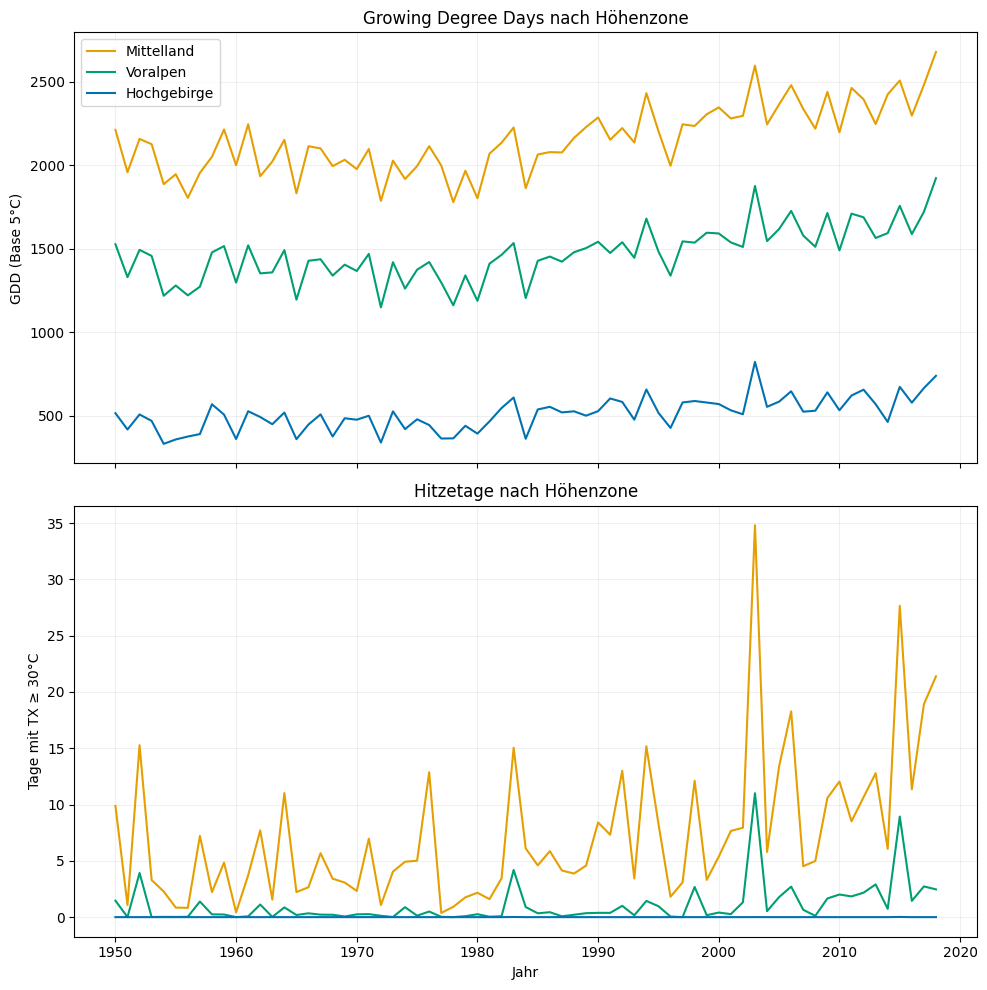

In [85]:
fig, axes = plt.subplots(2, 1, figsize=(10, 10), sharex=True)

# Farben aus der zentralen Okabe-Ito-Palette
colors = ZONEN_FARBEN

# --- Plot 1: GDD ---
axes[0].plot(gdd_mittelland.year, gdd_mittelland, color=colors["Mittelland"], label="Mittelland")
axes[0].plot(gdd_voralpen.year, gdd_voralpen, color=colors["Voralpen"], label="Voralpen")
axes[0].plot(gdd_hochgebirge.year, gdd_hochgebirge, color=colors["Hochgebirge"], label="Hochgebirge")

axes[0].set_title("Growing Degree Days nach Höhenzone")
axes[0].set_ylabel("GDD (Base 5°C)")
axes[0].legend()
axes[0].grid(alpha=0.2)

# --- Plot 2: Hitzetage ---
axes[1].plot(hot_mittelland.year, hot_mittelland, color=colors["Mittelland"], label="Mittelland")
axes[1].plot(hot_voralpen.year, hot_voralpen, color=colors["Voralpen"], label="Voralpen")
axes[1].plot(hot_hochgebirge.year, hot_hochgebirge, color=colors["Hochgebirge"], label="Hochgebirge")

axes[1].set_title("Hitzetage nach Höhenzone")
axes[1].set_ylabel("Tage mit TX ≥ 30°C")
axes[1].set_xlabel("Jahr")
axes[1].grid(alpha=0.2)

plt.tight_layout()
plt.show()

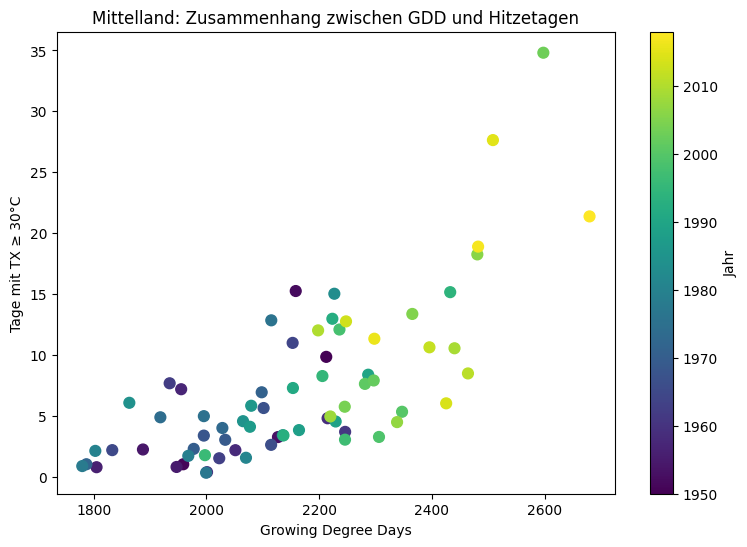

In [86]:
fig, ax = plt.subplots(figsize=(9, 6))

sc = ax.scatter(
    gdd_mittelland,
    hot_mittelland,
    c=gdd_mittelland.year,
    cmap="viridis",
    s=60
)

cbar = plt.colorbar(sc, ax=ax)
cbar.set_label("Jahr")

ax.set_title("Mittelland: Zusammenhang zwischen GDD und Hitzetagen")
ax.set_xlabel("Growing Degree Days")
ax.set_ylabel("Tage mit TX ≥ 30°C")

plt.show()

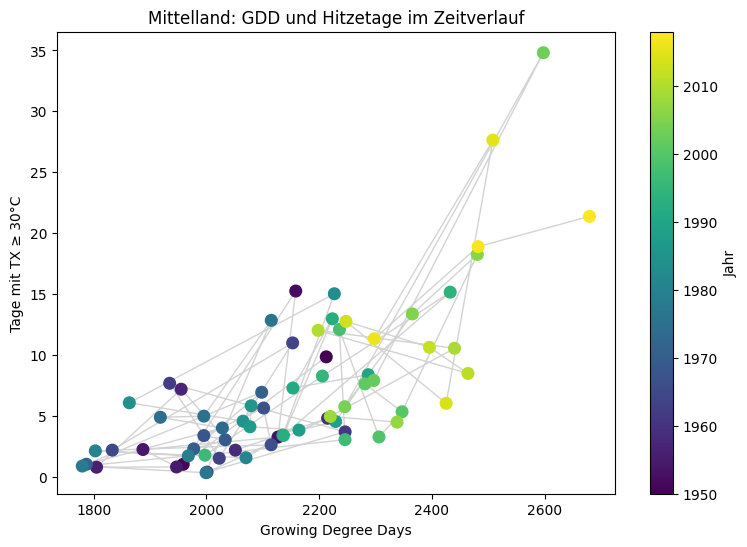

In [87]:
fig, ax = plt.subplots(figsize=(9, 6))

ax.plot(gdd_mittelland, hot_mittelland, color="lightgray", linewidth=1, zorder=1)

sc = ax.scatter(
    gdd_mittelland,
    hot_mittelland,
    c=gdd_mittelland.year,
    cmap="viridis",
    s=70,
    zorder=2
)

cbar = plt.colorbar(sc, ax=ax)
cbar.set_label("Jahr")

ax.set_title("Mittelland: GDD und Hitzetage im Zeitverlauf")
ax.set_xlabel("Growing Degree Days")
ax.set_ylabel("Tage mit TX ≥ 30°C")

plt.show()

In [88]:
years = gdd_mittelland.year.values
decades = (years // 10) * 10

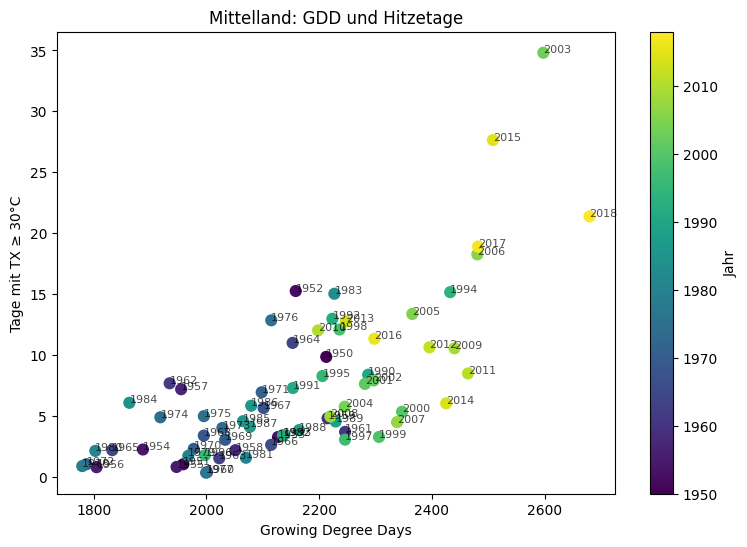

In [89]:
fig, ax = plt.subplots(figsize=(9, 6))

sc = ax.scatter(
    gdd_mittelland,
    hot_mittelland,
    c=gdd_mittelland.year,
    cmap="viridis",
    s=60
)

for x, y, year in zip(gdd_mittelland.values, hot_mittelland.values, gdd_mittelland.year.values):
    ax.text(x, y, str(year), fontsize=8, alpha=0.7)

cbar = plt.colorbar(sc, ax=ax)
cbar.set_label("Jahr")

ax.set_title("Mittelland: GDD und Hitzetage")
ax.set_xlabel("Growing Degree Days")
ax.set_ylabel("Tage mit TX ≥ 30°C")

plt.show()

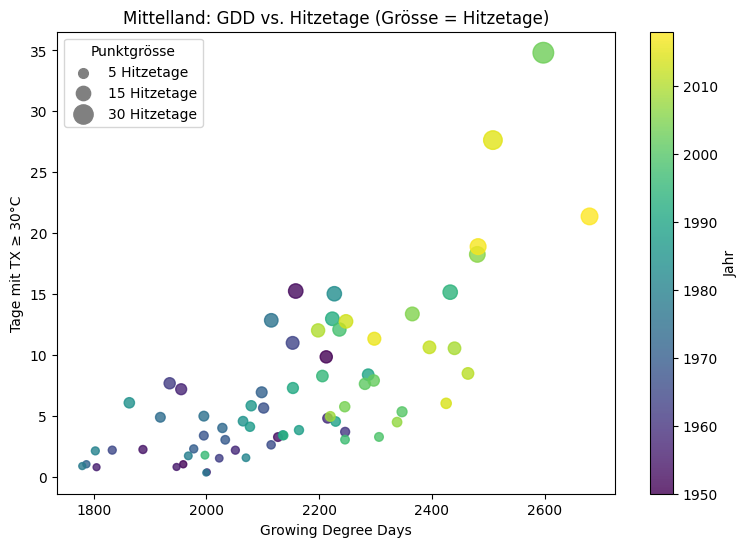

In [90]:
x = gdd_mittelland.values
y = hot_mittelland.values
years = gdd_mittelland.year.values

sizes = (y / y.max()) * 200 + 20   # Min-Grösse 20, Max 220

fig, ax = plt.subplots(figsize=(9, 6))

sc = ax.scatter(
    x,
    y,
    c=years,
    s=sizes,
    cmap="viridis",
    alpha=0.8,
    zorder=2
)

cbar = plt.colorbar(sc, ax=ax)
cbar.set_label("Jahr")

ax.set_title("Mittelland: GDD vs. Hitzetage (Grösse = Hitzetage)")
ax.set_xlabel("Growing Degree Days")
ax.set_ylabel("Tage mit TX ≥ 30°C")

for val in [5, 15, 30]:
    ax.scatter([], [], s=(val / y.max()) * 200 + 20,
               label=f"{val} Hitzetage", color="gray")

ax.legend(title="Punktgrösse")

plt.show()

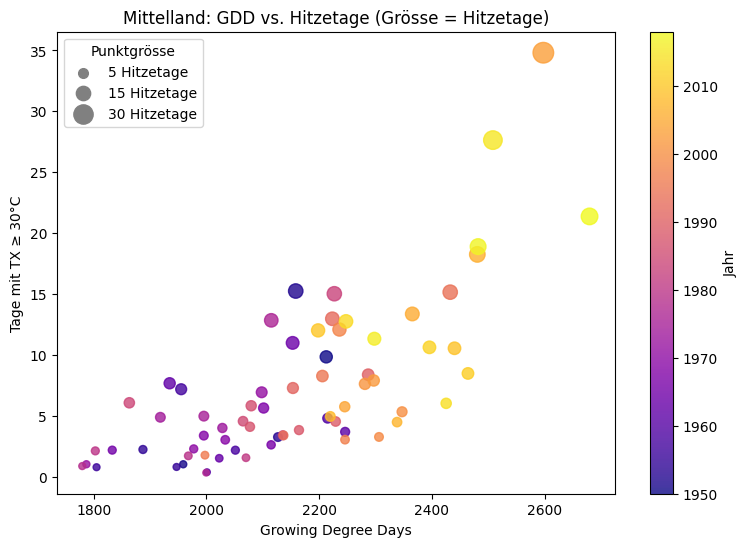

In [91]:
x = gdd_mittelland.values
y = hot_mittelland.values
years = gdd_mittelland.year.values

sizes = (y / y.max()) * 200 + 20   # Min-Grösse 20, Max 220

fig, ax = plt.subplots(figsize=(9, 6))

sc = ax.scatter(
    x,
    y,
    c=years,
    s=sizes,
    cmap="plasma",
    alpha=0.8,
    zorder=2
)

cbar = plt.colorbar(sc, ax=ax)
cbar.set_label("Jahr")

ax.set_title("Mittelland: GDD vs. Hitzetage (Grösse = Hitzetage)")
ax.set_xlabel("Growing Degree Days")
ax.set_ylabel("Tage mit TX ≥ 30°C")

for val in [5, 15, 30]:
    ax.scatter([], [], s=(val / y.max()) * 200 + 20,
               label=f"{val} Hitzetage", color="gray")

ax.legend(title="Punktgrösse")

plt.show()

### 6.8 Inversionslagen untersuchen

Die nachfolgende Visualisierung wurde nicht in das Dashboard übernommen, da der Erklärungsbedarf als zu hoch eingestuft wurde. Für die Erklärung einer Inversionslage eignen sich die Plots aus 5.4 besser.

Zudem war für die Berechnung die didaktische Vereinfachung der Höhenzonen nicht sehr förderlich und es musste mit Extremwerten gearbeitet werden.

Eine Verarbeitung ohne Höhenzonen wurde aus Zeitgründen nicht weiter verfolgt.

Differenz der "extremen" Temperaturmittel je Höhenzone ermitteln

In [92]:
low_temp = tg_ch.where(zone_tg == 1).quantile(0.2, dim=("latitude","longitude")) # 20%-Quantil der Temperaturen im Mittelland
high_temp = tg_ch.where(zone_tg == 3).quantile(0.8, dim=("latitude","longitude")) # 80%-Quantil der Temperaturen im Hochgebirge

delta = low_temp - high_temp

Kaltluftsee unten, freie Atmosphäre oben

Der Vergleich der reinen Tagesmittelwerte pro Zone zeigt den Rückgang der Inversionslagen nur ungenügend, da die Topologie der Schweiz doch sehr komplex d.h. nicht linear ist (vergl. LinkedIn-Beitrag von Klimatologe Simon Scherer, Uni Bern, von Mitte März 2026, Paper vom November 2025)

In [93]:
inv_df = delta.to_dataframe(name="delta").reset_index()
inv_df["year"] = inv_df["time"].dt.year
inv_df["month"] = inv_df["time"].dt.month

inv_winter = inv_df[inv_df["month"].isin([11,12,1,2])] # Wintermonate

inv_winter["is_inversion"] = inv_winter["delta"] < 0

Anteile Inversionstage pro Jahr

In [94]:
inv_share = inv_winter.groupby("year")["is_inversion"].mean() * 100 # Anteile

inv_smooth = inv_share.rolling(9, center=True).mean() #gleitendes Fenster (moving average) z.B. für 1980 werden die 4 Jahre davor und danach gemittelt mit center = True: 1980 liegt in der Mitte

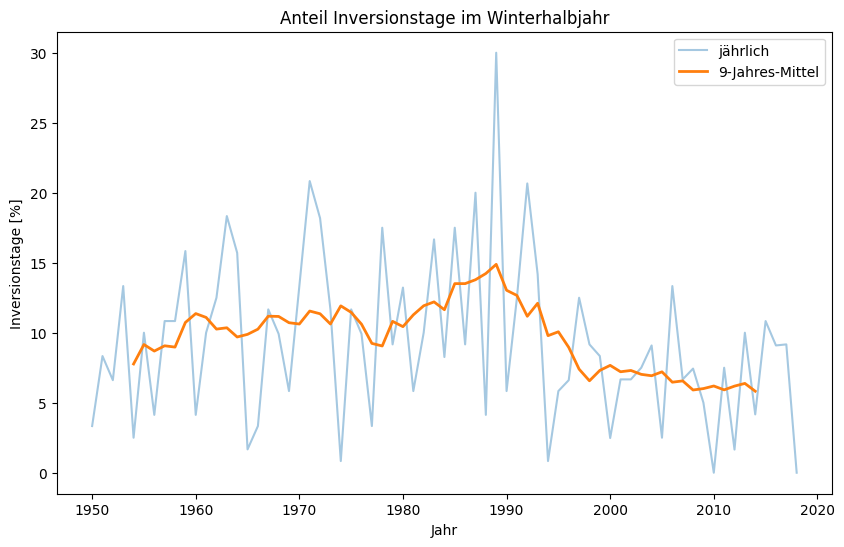

In [95]:
plt.figure(figsize=(10,6))

plt.plot(inv_share.index, inv_share.values, alpha=0.4, label="jährlich")
plt.plot(inv_smooth.index, inv_smooth.values, linewidth=2, label="9-Jahres-Mittel")

plt.legend()
plt.title("Anteil Inversionstage im Winterhalbjahr")
plt.xlabel("Jahr")
plt.ylabel("Inversionstage [%]")

plt.show()